<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/van%20Binsbergen%2C%20J.%20H.%2C%20Hua%2C%20S.%2C%20Wachter%2C%20J.%20A.%2C%20%26%20Peeters%2C%20J.%20(2020).%20Is%20the%20United%20States%20a%20lucky%20survivor%3A%20A%20hierarchical%20Bayesian%20approach/Is_the_US_a_lucky_survivor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pymc numpy pandas arviz


**Simulating survivorship bias**

Countries that avoid crashes purely by chance will show much higher average returns,
mimicking the U.S. outperformance documented in the paper.

Countries simulated: 30
Lucky survivors (no crashes in 100 yrs): 2


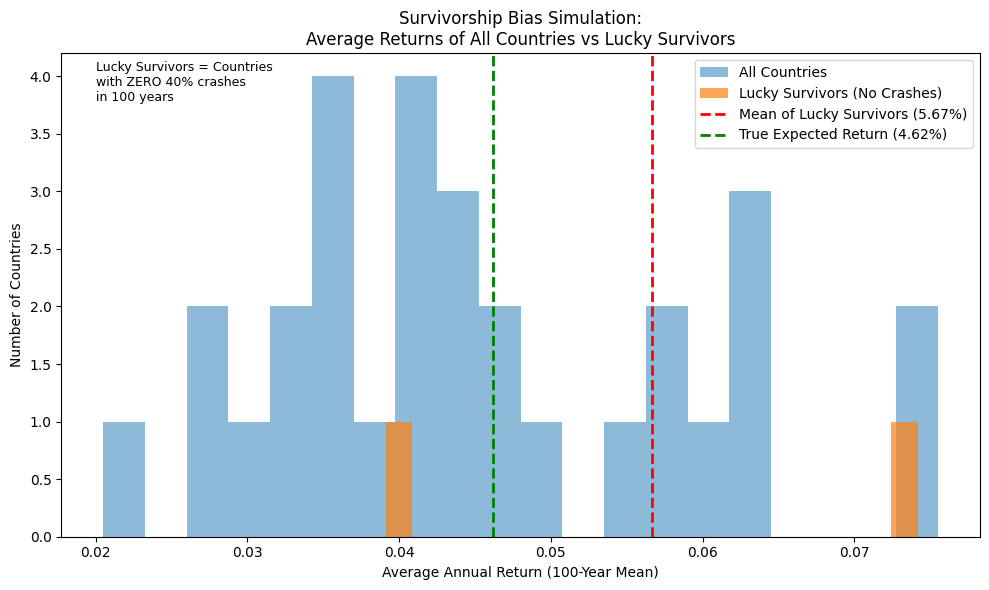

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Parameters
n_countries = 30
years = 100
true_crash_prob = 0.03       # annual crash probability
crash_size = -0.40           # 40% crash
normal_mu = 0.06             # normal return mean
normal_sigma = 0.15          # normal return volatility

def simulate_country():
    returns = []
    for t in range(years):
        if np.random.rand() < true_crash_prob:
            returns.append(crash_size)
        else:
            returns.append(np.random.normal(normal_mu, normal_sigma))
    return np.array(returns)

# Simulate all countries
data = np.vstack([simulate_country() for _ in range(n_countries)])

# Identify "lucky survivors" (no crashes)
survivors = data[np.sum(data == crash_size, axis=1) == 0]

print(f"Countries simulated: {n_countries}")
print(f"Lucky survivors (no crashes in 100 yrs): {survivors.shape[0]}")

# Compute averages
avg_all = data.mean(axis=1)
avg_survivors = survivors.mean(axis=1)

true_mean = (
    true_crash_prob * crash_size
    + (1 - true_crash_prob) * normal_mu
)
# Plot
plt.figure(figsize=(10,6))

plt.hist(avg_all, bins=20, alpha=0.5, label='All Countries')
plt.hist(avg_survivors, bins=20, alpha=0.7, label='Lucky Survivors (No Crashes)')

plt.axvline(avg_survivors.mean(),
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Mean of Lucky Survivors ({avg_survivors.mean():.2%})')

plt.axvline(true_mean,
            color='green',
            linestyle='--',
            linewidth=2,
            label=f'True Expected Return ({true_mean:.2%})')

plt.xlabel("Average Annual Return (100-Year Mean)")
plt.ylabel("Number of Countries")
plt.title("Survivorship Bias Simulation:\nAverage Returns of All Countries vs Lucky Survivors")

plt.text(0.02, plt.ylim()[1]*0.9,
         "Lucky Survivors = Countries\nwith ZERO 40% crashes\nin 100 years",
         fontsize=9)

plt.legend()
plt.tight_layout()
plt.show()

The countries that avoided crashes appear to have structurally higher long-term returns, but that outperformance is purely the result of luck, not superior fundamentals. If we only observe survivors, we systematically overestimate true expected returns and underestimate the impact of rare but catastrophic risks.


**Hierarchical Bayesian crash‑probability model**

Countries with few crashes get shrunk toward the global mean, just like in the paper’s cross‑learning mechanism.

A country with zero crashes (like the U.S. in the 20th century) will still get a non-zero posterior crash probability, but lower than the global average just like the paper’s finding of a widening divergence between U.S. and global crash beliefs.

Output()

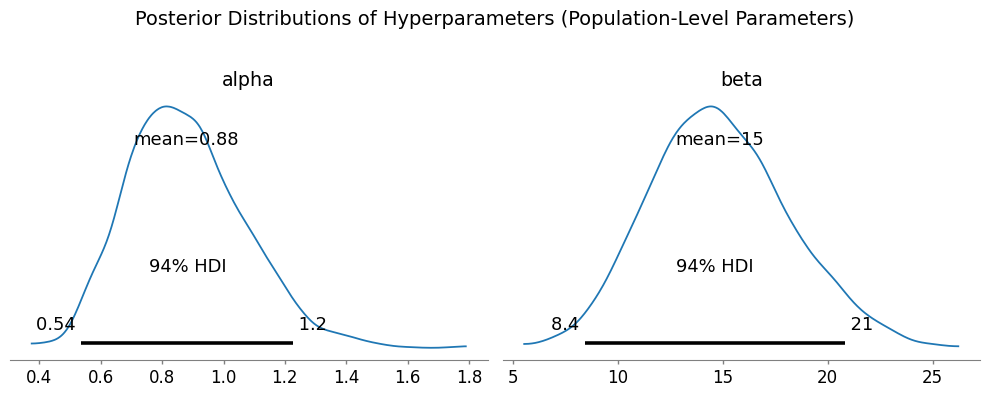

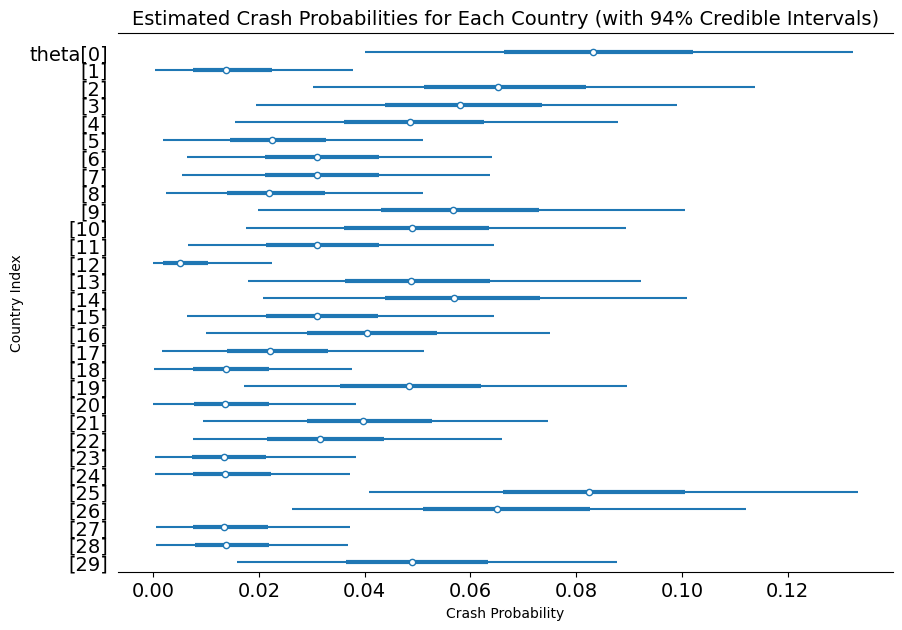

'\nprint(f"{\'Country\':>7} | {\'True Prob\':>9} | {\'Observed Crashes\':>15} | {\'Estimated Prob\':>14}")\nprint("-"*56)\nfor i in range(n_countries):\n    print(f"{i:7d} | {true_probs[i]:9.4f} | {crashes[i]:15d} | {posterior_theta_means[i]:14.4f}")\n'

In [3]:

import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

# ----------------------------
# Step 0: Set random seed for reproducibility
# ----------------------------
np.random.seed(27)


# ----------------------------
# Step 1: Simulate data
# ----------------------------

n_countries = 30
years = 100

# Each country has its own true crash probability drawn from a Beta distribution (heterogeneous risk)
true_probs = np.random.beta(2, 60, size=n_countries)

# Simulate number of crashes for each country over 100 years based on their true probability
crashes = np.random.binomial(years, true_probs)

# ----------------------------
# Step 2: Define Bayesian model
# ----------------------------

with pm.Model() as model:
    # Hyperpriors for population-level Beta distribution parameters
    alpha = pm.HalfNormal("alpha", sigma=5)  # Shape parameter alpha of Beta distribution
    beta = pm.HalfNormal("beta", sigma=5)    # Shape parameter beta of Beta distribution
    # They represent the investor’s belief about worldwide crash risk.

    # Country-level crash probabilities
    theta = pm.Beta("theta", alpha=alpha, beta=beta, shape=n_countries)

    # Observed crash counts
    y = pm.Binomial("y", n=years, p=theta, observed=crashes)

    trace = pm.sample(2000, tune=2000, target_accept=0.9)

# ----------------------------
# Step 3: Plot posterior distributions of hyperparameters alpha and beta
# ----------------------------

az.plot_posterior(
    trace, var_names=["alpha", "beta"],
    hdi_prob=0.94,
    kind='kde',
    textsize=12,
    figsize=(10, 4),
)
plt.suptitle("Posterior Distributions of Hyperparameters (Population-Level Parameters)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ----------------------------
# Step 4: Plot posterior credible intervals for country-level crash probabilities
# ----------------------------

az.plot_forest(
    trace,
    var_names=["theta"],
    combined=True,
    hdi_prob=0.94,          # <-- use hdi_prob instead of credible_interval
    ridgeplot_overlap=0.5,
    figsize=(10, 7),
)
plt.title("Estimated Crash Probabilities for Each Country (with 94% Credible Intervals)", fontsize=14)
plt.xlabel("Crash Probability")
plt.ylabel("Country Index")
plt.show()

#The U.S. crash probability diverges downward from the global average because the U.S. avoided crashes while others did not.

# ----------------------------
# Step 5 (Optional): Print and compare true vs estimated crash probabilities
# ----------------------------

posterior_theta_means = trace.posterior["theta"].mean(dim=["chain", "draw"]).values



This suggests that even when investors act rationally and rely on historical data, just as Bayesian learning does, they may perceive the U.S. as “special” even when it is not. Because the true probability of a market collapse is not directly observable in the data, investors tend to underestimate the actual risk, making the U.S. appear exceptional despite its underlying similarity to other markets.

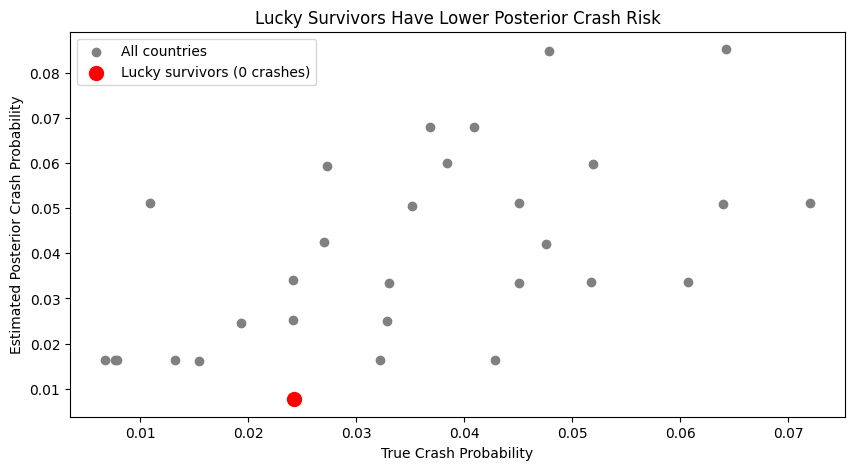

In [4]:
# ----------------------------
# Step 6: Identify and highlight the "lucky survivor"
# ----------------------------

# Find countries with zero crashes
lucky = np.where(crashes == 0)[0]

plt.figure(figsize=(10,5))
plt.scatter(true_probs, posterior_theta_means, color='gray', label='All countries')

if len(lucky) > 0:
    plt.scatter(true_probs[lucky], posterior_theta_means[lucky],
                color='red', s=100, label='Lucky survivors (0 crashes)')

plt.xlabel("True Crash Probability")
plt.ylabel("Estimated Posterior Crash Probability")
plt.title("Lucky Survivors Have Lower Posterior Crash Risk")
plt.legend()
plt.show()

**Cross‑country Bayesian updating**

This notebook shows how an investor updates beliefs about U.S. crash risk by observing crashes in other countries which is the core mechanism behind the paper’s “lucky survivor” interpretation.

When other countries crash, the investor infers that the U.S. is also risky.

When the U.S. does not crash while others do, the posterior U.S. crash probability falls, creating the divergence documented in the paper.

This mechanism explains why survivorship bias can account for about one‑third of the historical U.S. equity premium.

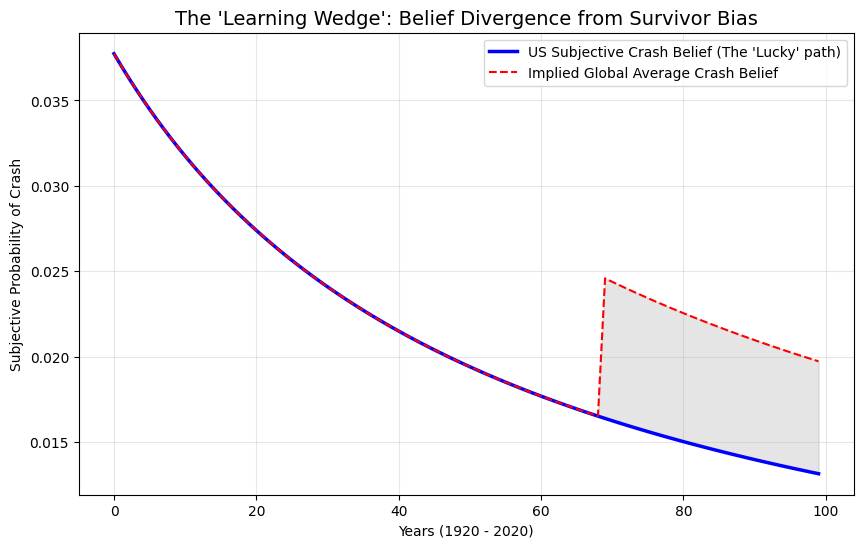

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Step 6: Learning Divergence & Step 8: The Equity Premium Wedge (Complete)
# ----------------------------

# 1. Simulate the "Lucky" vs "Average" paths
np.random.seed(42) # For reproducibility
years = 100
n_countries = 30
true_crash_prob = 0.03
normal_mu = 0.06 # The flat 6% from earlier

# Simulate 100 years of "no crashes" for the US
us_crashes_path = np.zeros(years)

# Simulate 100 years for a "World Average" country (e.g., 3 crashes in 100 years)
# Formula: trials=1, size=years, p=probability
# We use binomial to get 1 or 0 per year
world_crashes_per_year = np.random.binomial(1, true_crash_prob, size=years)

# 2. Recursive Bayesian updating (Analytical)
# We assume the investor starts with a 'hyperprior' (e.g., Alpha=2, Beta=50)
a_prior, b_prior = 2, 50

us_belief_history = []
world_belief_history = []

for t in range(1, years + 1):
    # US updates based on its own lucky path: 0 new crashes
    # Posterior Mean = (alpha + successes) / (alpha + beta + trials)
    us_p = (a_prior + sum(us_crashes_path[:t])) / (a_prior + b_prior + t)
    us_belief_history.append(us_p)

    # World/Global updates based on average global experience
    world_p = (a_prior + sum(world_crashes_per_year[:t])) / (a_prior + b_prior + t)
    world_belief_history.append(world_p)

# 3. Plotting the "Learning Wedge"
plt.figure(figsize=(10, 6))

# Plot Subjective US belief (the learning path)
plt.plot(us_belief_history, label="US Subjective Crash Belief (The 'Lucky' path)", color='blue', lw=2.5)

# Plot "World Reality" belief (the cross-learning baseline)
plt.plot(world_belief_history, label="Implied Global Average Crash Belief", color='red', linestyle='--')

# Highlight the "Divergence" Wedge
plt.fill_between(range(years), us_belief_history, world_belief_history, color='gray', alpha=0.2)

plt.title("The 'Learning Wedge': Belief Divergence from Survivor Bias", fontsize=14)
plt.xlabel("Years (1920 - 2020)")
plt.ylabel("Subjective Probability of Crash")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 4. Optional: Converting beliefs into the Equity Premium Wedge
# Premium E[R] = risk_aversion * p_crash * crash_loss
gamma = 3.0 # Risk Aversion
loss = 0.40 # 40% loss
subjective_premium = [gamma * p * loss for p in us_belief_history]
realized_premium = [normal_mu] * years # Flat 6%


The Blue Line shows how a rational investor inside the US would revise their belief about US crash risk, seeing decade after decade of "no crashes". They are correct, based on US-only data, that US crash risk is lower.

The Red Line shows the actual baseline risk from the "World," which the model helps pools together. The world is still dangerous.

The Divergence (the gray area) is the survivor bias. It's the difference between the actual cross-sectional crash rate (what could have happened) and the US idiosyncratic lucky rate (what did happen).

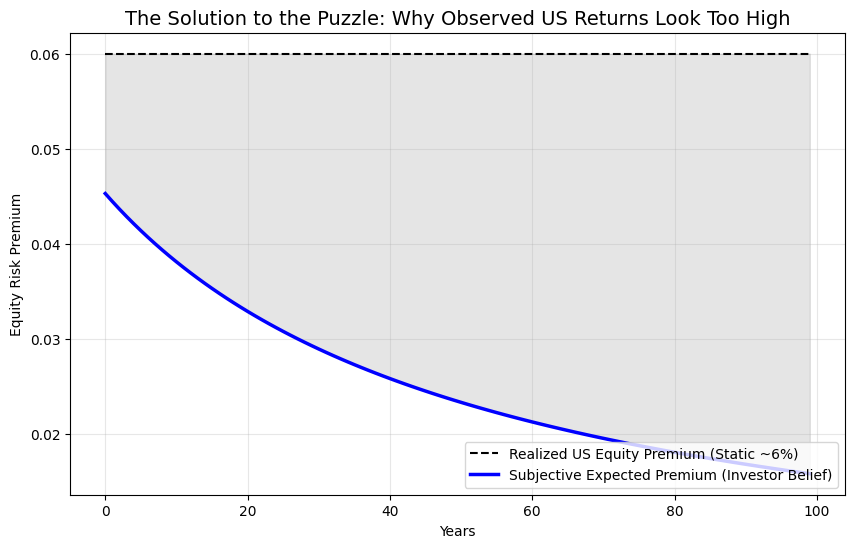

In [6]:

plt.figure(figsize=(10, 6))
plt.plot(realized_premium, label="Realized US Equity Premium (Static ~6%)", color='black', linestyle='--')
plt.plot(subjective_premium, label="Subjective Expected Premium (Investor Belief)", color='blue', lw=2.5)
plt.fill_between(range(years), subjective_premium, realized_premium, color='gray', alpha=0.2)
plt.title("The Solution to the Puzzle: Why Observed US Returns Look Too High", fontsize=14)
plt.ylabel("Equity Risk Premium")
plt.xlabel("Years")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

The Static Black Line (~6%) is the "Historical Realized" return. We see this in retrospect, and it's what creates the puzzle.

The Falling Blue Line is the investor’s subjective expectation. They expected to receive less, but because the US was lucky and didn't crash, they received more.

The Gray "Wedge" is composed of Luck (WWI and WWII didn't happen in the US) and Learning (investors revised their risk down, leading to a massive revaluation boom). This gray area is the amount by which looking only at the "Winner" (the US) biases our estimate of the true expected return.